# PCN on MNIST

Digit classification and class-conditional generation with the predictive-coding network.

In [1]:
from math import ceil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from pcn.model import PredictiveCodingNetwork
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm


In [2]:
# Test Again with MNIST (Also test generation this time)

# Define transformations for the MNISTdataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load MNIST training and test datasets
train_dataset_mnist = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
test_dataset_mnist = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# Train/Validation-Split aus dem Trainingsset - Test erst am Ende.
fit_mnist, val_mnist = random_split(
    train_dataset_mnist, [55000, 5000], generator=torch.Generator().manual_seed(42)
)

# fit()/evaluate() nehmen die Datasets direkt und bauen den Loader selbst.
# Nur die manuelle Test-Schleife unten braucht einen eigenen Loader.
test_loader_mnist = DataLoader(test_dataset_mnist, batch_size=256, shuffle=False)


In [3]:
MNIST_input_dim = int(np.prod(train_dataset_mnist[0][0].shape))
MNIST_num_classes = len(train_dataset_mnist.classes)

# Warnung: die Relaxation laeuft T_infer mal pro Batch, das dominiert die Laufzeit.
# Erst mit wenigen Epochen testen bevor man hochdreht.
pcn_mnist = PredictiveCodingNetwork(
    dims=[MNIST_input_dim,  512, 128],
    output_dim=MNIST_num_classes
)

mnist_history = pcn_mnist.fit(
    fit_mnist,
    num_epochs=10,
    eta_infer=0.1,      # 0.01 war zu klein: die Relaxation kam nie am Fixpunkt an
    T_infer=100,
    batch_size=128,     # groessere Batches -> weniger Python-Overhead pro Schritt
    optimizer=torch.optim.Adam(pcn_mnist.parameters(), lr=1e-3, weight_decay=0.05),
    T_learn=1,
    validation_data=val_mnist,   # Test erst nach dem Training
    device="cuda",
    eval_every=5,
)


100%|██████████| 10/10 [02:44<00:00, 16.41s/it]


In [4]:
predicted_list = []
true_labels_list = []

# Gradientenberechnung ausschalten spart Speicher und Zeit
with torch.no_grad():
    for images, labels in test_loader_mnist:
        # Bilder flachklopfen für das PCN
        images_flat = images.view(images.size(0), -1)
        
        # Direkt den Batch in den Predict-Modus füttern
        result = pcn_mnist.run(mode="predictive", x=images_flat, eta_infer=0.1, T_infer=100)
        
        # Vorhersagen (Argmax) für diesen Batch berechnen
        batch_preds = result.output_prediction.argmax(dim=1)
        
        predicted_list.append(batch_preds.cpu())
        true_labels_list.append(labels.cpu())

# Alle Batches für die Metriken zusammenführen
predicted_classes = torch.cat(predicted_list, dim=0)
y_test_MNIST = torch.cat(true_labels_list, dim=0)

# Metriken berechnen (wie in Ihrem Originalcode)
print("Test Accuracy:", accuracy_score(y_test_MNIST, predicted_classes))
print("Test F1 Score:", f1_score(y_test_MNIST, predicted_classes, average='macro')) 

Test Accuracy: 0.8478
Test F1 Score: 0.8444775014706917


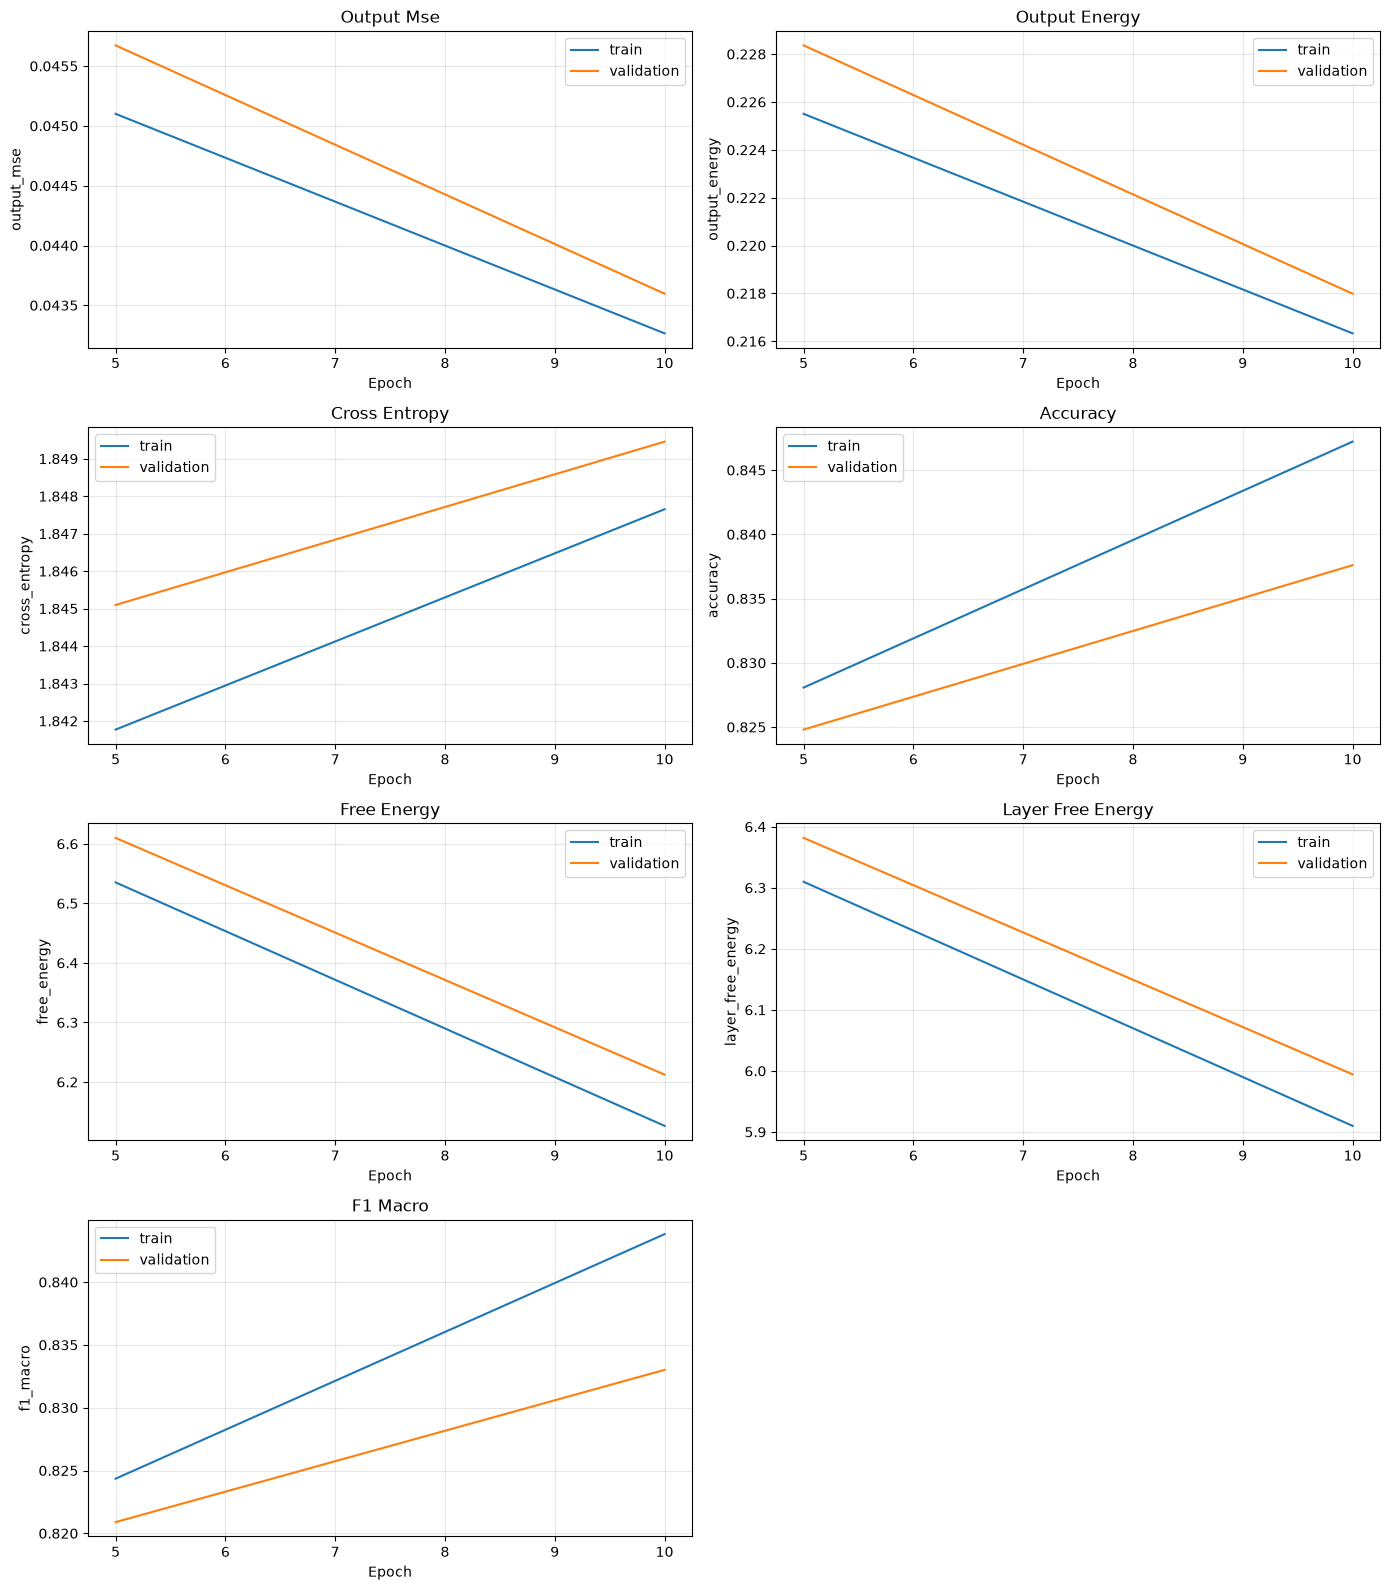

beste Validation-F1 (macro) 0.8330 bei Epoche 10


In [5]:
mnist_train_history = pd.DataFrame(mnist_history["train"], index=mnist_history["epoch"])
mnist_val_hist = pd.DataFrame(mnist_history["validation"], index=mnist_history["epoch"])

# mnist_history ist ein dict, kein DataFrame - Spalten kommen aus dem DataFrame.
metrics = [c for c in mnist_train_history.columns if c != "n"]
n_plots = len(metrics)
n_cols = 2
n_rows = ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = np.array(axes).ravel()

for i, metric in enumerate(metrics):
	axes[i].plot(mnist_train_history[metric], label="train", color="tab:blue")
	if not mnist_val_hist.empty and metric in mnist_val_hist.columns:
		axes[i].plot(mnist_val_hist[metric], label="validation", color="tab:orange")
	axes[i].set_title(metric.replace("_", " ").title())
	axes[i].set_xlabel("Epoch")
	axes[i].set_ylabel(metric)
	axes[i].legend()
	axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
	axes[j].axis("off")

plt.tight_layout()
plt.show()

# Beste Epoche nach Validation waehlen - nicht nach Test.
# MNIST hat 10 Klassen, also f1_macro; "f1" gibt es nur im 2-Klassen-Fall.
best = mnist_val_hist["f1_macro"].idxmax()
print(f"beste Validation-F1 (macro) {mnist_val_hist['f1_macro'].max():.4f} bei Epoche {best}")


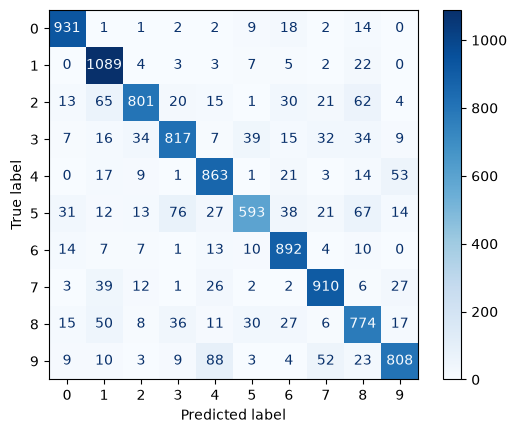

In [6]:
# Confusion Matrix
# y_test_tensor waeren die Herz-Labels (230 Zeilen) gegen 10000 MNIST-Vorhersagen.
cm = confusion_matrix(y_test_MNIST, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(MNIST_num_classes)))
disp.plot(cmap=plt.cm.Blues)
plt.show()

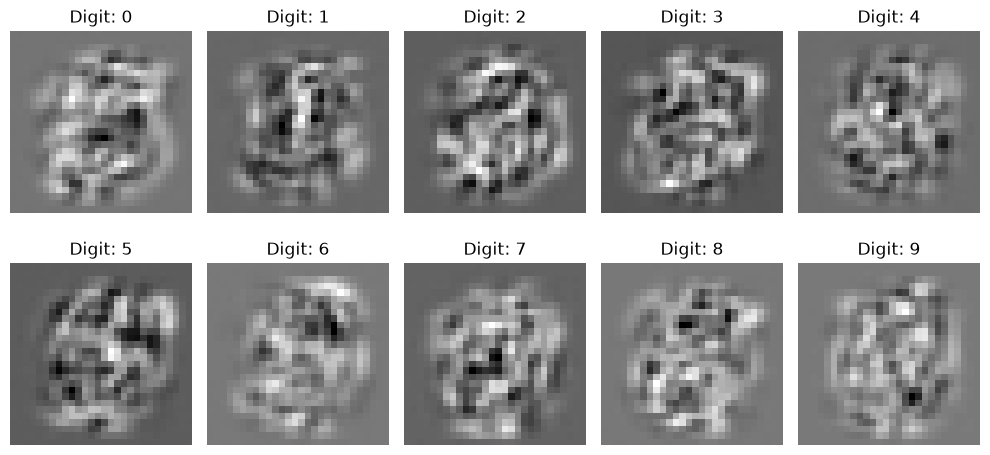

In [7]:

# Erstellt eine Figur mit passender Größe für ein 3x3 Raster
fig = plt.figure(figsize=(10, 5))

for digit in range(10):
    # Generiert das Bild für die aktuelle Ziffer (0 bis 8)
    image = pcn_mnist.run(mode="generative", y=digit, eta_infer=0.1, T_infer=100)
    
    # Umformen in 28x28 Pixel
    image_2d = image.input_state.view(28, 28)
    
    # Definiert die Position im 3x3 Raster (Index startet bei 1)
    plt.subplot(2, 5, digit + 1)
    
    # Bild im Subplot anzeigen
    plt.imshow(image_2d.cpu().numpy(), cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')  # Blendet die Achsen aus

# Optimiert die Abstände zwischen den Bildern, damit nichts überlappt
plt.tight_layout()
plt.show()


100%|██████████| 10/10 [00:22<00:00,  2.21s/it]


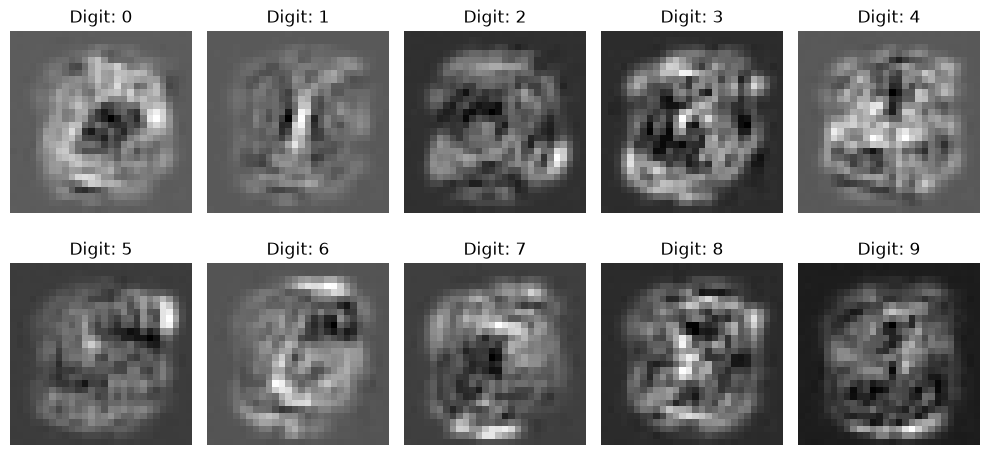

In [8]:
# Erstellt eine Figur mit passender Größe für ein 3x3 Raster
fig = plt.figure(figsize=(10, 5))
n = 100  # Anzahl der Bilder pro Ziffer
mnist_device = next(pcn_mnist.parameters()).device

for digit in tqdm(range(10)):
    image_sum = torch.zeros((28, 28), device=mnist_device)  # Summe der Bilder initialisieren
    for _ in range(n):  # Generiere 100 Bilder pro Ziffer and plot the average
        # Generiert das Bild für die aktuelle Ziffer (0 bis 8)
        image = pcn_mnist.run(mode="generative", y=digit, eta_infer=0.1, T_infer=100)
        image_sum += image.input_state.view(28, 28)

    # Durchschnittsbild berechnen
    image_2d = image_sum / n

    # Definiert die Position im 3x3 Raster (Index startet bei 1)
    plt.subplot(2, 5, digit + 1)

    # Bild im Subplot anzeigen
    plt.imshow(image_2d.cpu().numpy(), cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')  # Blendet die Achsen aus

# Optimiert die Abstände zwischen den Bildern, damit nichts überlappt
plt.tight_layout()
plt.show()